In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
path = "/content/drive/MyDrive/Mecine Learning/Praktikum10"

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt    # visualisasi dasar
import seaborn as sns              # visualisasi lebih menarik

##Baca Dataset


In [15]:
df = pd.read_excel('/content/drive/MyDrive/Mecine Learning/Praktikum10/data/weather_classification_data.xlsx')
display(df.head())

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14,73,9.5,82,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39,96,8.5,71,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30,64,7.0,16,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38,83,1.5,82,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27,74,17.0,66,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  int64  
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  int64  
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 1.1+ MB


In [17]:
df_num = df.select_dtypes(include=['int64', 'float64'])
df_num.head()


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
0,14,73,9.5,82,1010.82,2,3.5
1,39,96,8.5,71,1011.43,7,10.0
2,30,64,7.0,16,1018.72,5,5.5
3,38,83,1.5,82,1026.25,7,1.0
4,27,74,17.0,66,990.67,1,2.5


In [18]:
correlation_matrix = df_num.corr(method='spearman')


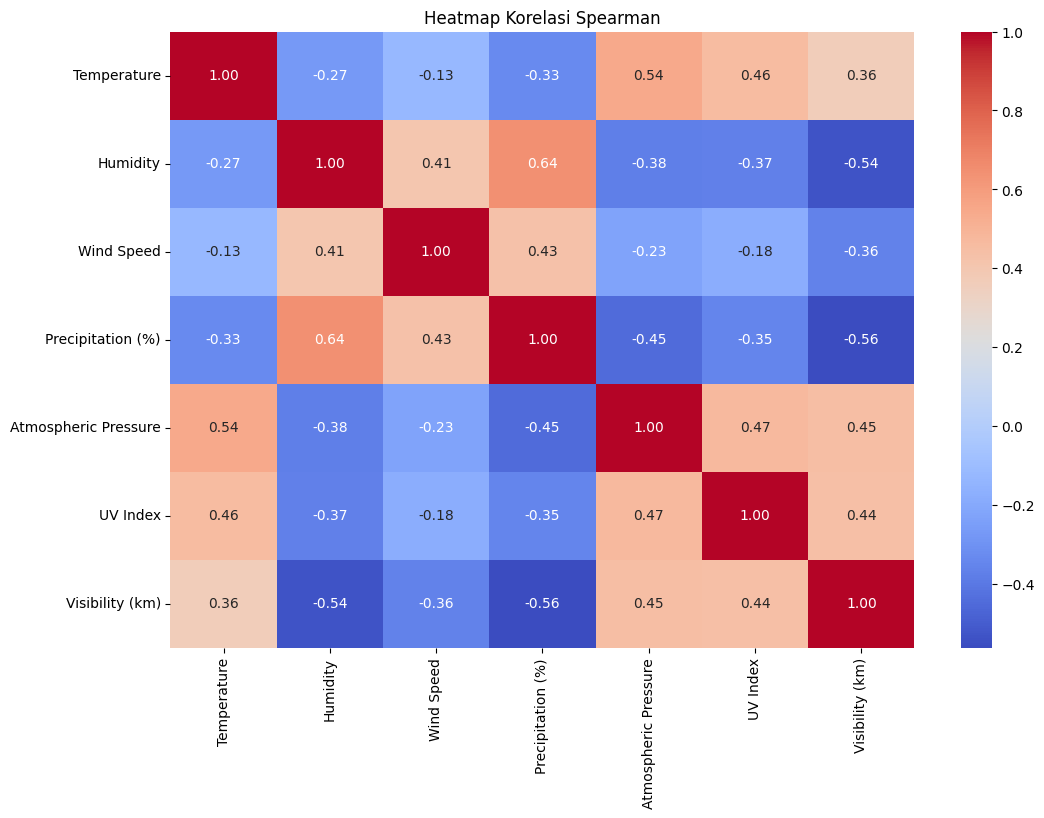

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Heatmap Korelasi Spearman")
plt.show()


In [20]:
# Label encoding untuk kolom kategori
label_cols = ["Cloud Cover", "Season", "Location", "Weather Type"]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

##Pisah fitur dan label

In [21]:
X = df.drop("Weather Type", axis=1)
y = df["Weather Type"]

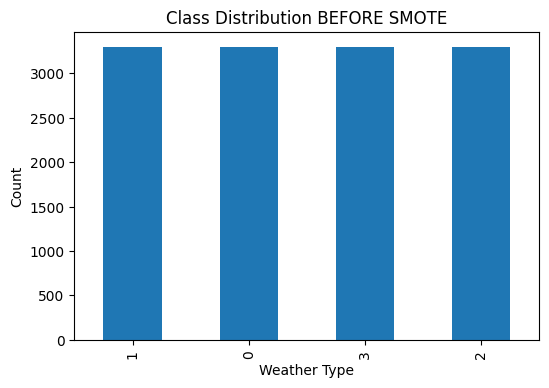

In [22]:
plt.figure(figsize=(6,4))
y.value_counts().plot(kind='bar')
plt.title("Class Distribution BEFORE SMOTE")
plt.xlabel("Weather Type")
plt.ylabel("Count")
plt.show()


In [23]:
sm = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = sm.fit_resample(X, y)

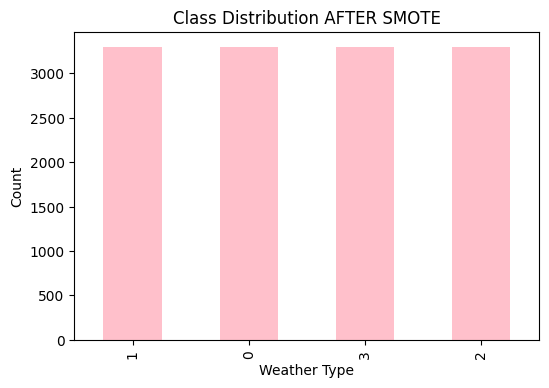

In [24]:
plt.figure(figsize=(6,4))
y_res.value_counts().plot(kind='bar', color='pink')
plt.title("Class Distribution AFTER SMOTE")
plt.xlabel("Weather Type")
plt.ylabel("Count")
plt.show()


In [26]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X_res)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.2, random_state=42
)

In [28]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=2, # Changed cv from 5 to 2
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best Score: 0.8982007575757576


In [30]:
# TRAIN MODEL WITH BEST PARAMS

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

In [31]:
# CONFUSION MATRIX (BEST PARAMS)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Best Params):")
print(cm)

Confusion Matrix (Best Params):
[[570  55  10  16]
 [ 52 567  17  11]
 [ 14  17 655  15]
 [ 40  25  14 562]]


In [32]:
# METRICS: ACCURACY, PRECISION, RECALL

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")

print("\nAccuracy:", round(acc*100, 2), "%")
print("Precision:", round(prec*100, 2), "%")
print("Recall:", round(rec*100, 2), "%")


Accuracy: 89.17 %
Precision: 89.22 %
Recall: 89.08 %


In [33]:
# CROSS VALIDATION & STD DEV

cv_scores = cross_val_score(best_knn, X_scaled, y_res, cv=3)

print("\nCross Validation Accuracy:", cv_scores.mean())
print("Std Deviation:", cv_scores.std())


Cross Validation Accuracy: 0.8967424242424243
Std Deviation: 0.0049804484587556465


In [34]:
# CLASSIFICATION REPORT

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       651
           1       0.85      0.88      0.86       647
           2       0.94      0.93      0.94       701
           3       0.93      0.88      0.90       641

    accuracy                           0.89      2640
   macro avg       0.89      0.89      0.89      2640
weighted avg       0.89      0.89      0.89      2640

